# AOS_RSO-250_Test_impact_of_zk_cutoff

Use the in-focus FAM dataset recently processed in `repo/embargo` . as `aos_cwfs_danish_triplets_infocus` 

In [2]:
import numpy as np
from lsst.daf import butler as dafButler
import astropy.units as u

butler = dafButler.Butler('embargo')
collection = 'aos_cwfs_danish_triplets_infocus'
det = 191 
dataRefs = list(butler.registry.queryDatasets('donutStampsExtra', 
                         collections=[collection],
                         detector=det, 
                         where=f"instrument='LSSTCam'  ").expanded()
           )


In [3]:
len(dataRefs)

797

ok, submit these for processing with a different threshold... We don't even need to rerun Zk fitting, just the sigma-clipping part, and test different clipping thresholds 

So actually we only need the `zernikes` dataset, and the flag `Used` is a result of `blur clipping` and `Zk clipping`. 

In [4]:
dataRefs = list(butler.registry.queryDatasets('zernikes', 
                         collections=[collection],
                         detector=det, 
                         where=f"instrument='LSSTCam'  ").expanded()
           )


In [6]:
zk = butler.get(dataRefs[0])

In [21]:
np.array(zk['used'].data)

array([ True,  True, False,  True,  True,  True,  True,  True, False,
       False, False,  True,  True,  True])

In [19]:
~np.array(zk.meta['estimatorInfo']['blur_clipped'])

array([ True, False,  True,  True,  True,  True,  True, False, False,
        True,  True,  True,  True])

In [25]:
zk

label,used,"intra_field [x, y]","extra_field [x, y]","intra_centroid [x, y]","extra_centroid [x, y]",intra_mag,extra_mag,intra_sn,extra_sn,intra_entropy,extra_entropy,intra_frac_bad_pix,extra_frac_bad_pix,intra_max_power_grad,extra_max_power_grad,intra_donut_id,extra_donut_id,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16,Z17,Z18,Z19,Z22,Z23,Z24,Z25,Z26,Z4_intrinsic,Z5_intrinsic,Z6_intrinsic,Z7_intrinsic,Z8_intrinsic,Z9_intrinsic,Z10_intrinsic,Z11_intrinsic,Z12_intrinsic,Z13_intrinsic,Z14_intrinsic,Z15_intrinsic,Z16_intrinsic,Z17_intrinsic,Z18_intrinsic,Z19_intrinsic,Z22_intrinsic,Z23_intrinsic,Z24_intrinsic,Z25_intrinsic,Z26_intrinsic,Z4_deviation,Z5_deviation,Z6_deviation,Z7_deviation,Z8_deviation,Z9_deviation,Z10_deviation,Z11_deviation,Z12_deviation,Z13_deviation,Z14_deviation,Z15_deviation,Z16_deviation,Z17_deviation,Z18_deviation,Z19_deviation,Z22_deviation,Z23_deviation,Z24_deviation,Z25_deviation,Z26_deviation
,,deg,deg,pix,pix,,,,,,,,,,,,,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm,nm
str7,bool,"(float32, float32)","(float32, float32)","(float32, float32)","(float32, float32)",float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str21,str21,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
average,True,"(nan, nan)","(nan, nan)","(nan, nan)","(nan, nan)",nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,--,--,-480.1849060058594,-211.21836853027344,288.91644287109375,-65.43333435058594,20.049236297607422,-55.10626220703125,70.02410125732422,-22.342269897460938,-49.120601654052734,-141.8544921875,276.8675842285156,74.39923858642578,-32.15336227416992,168.56573486328125,-34.215824127197266,-2.357844114303589,11.839694023132324,26.633182525634766,39.77695846557617,2.1095499992370605,-59.08858108520508,-35.17802047729492,-20.258243560791016,17.842782974243164,-27.973312377929688,-29.88267707824707,-100.69084930419922,99.39990997314453,-44.34752655029297,-4.345801830291748,8.62588119506836,1.3437738418579102,-1.6611543893814087,5.9881768226623535,6.603830337524414,-14.062460899353027,16.642850875854492,-6.712181091308594,13.690875053405762,0.014747434295713902,-0.1416551172733307,0.8326692581176758,-445.00689697265625,-190.9601593017578,271.0736083984375,-37.46002197265625,49.93191146850586,45.58457946777344,-29.37580108642578,22.00525665283203,-44.77479553222656,-150.4803924560547,275.5238037109375,76.06038665771484,-38.14154052734375,161.9619140625,-20.153364181518555,-19.000696182250977,18.5518741607666,12.942310333251953,39.76220703125,2.251204490661621,-59.92125701904297
pair1,True,"(-1.0887213, -1.2112514)","(-1.2497879, -1.0847247)","(3856.0, 1776.0)","(3118.0, 272.0)",nan,nan,50835.094,53932.316,1.5110013,1.5083424,0.0,0.0,0.30051386,0.5165858,2026031500074_192_000,2026031500074_191_000,-373.63531494140625,-55.96629333496094,12.534812927246094,-142.1580352783203,-172.37298583984375,-66.93106842041016,29.696685791015625,62.17900848388672,23.227462768554688,-177.69505310058594,201.50723266601562,30.413185119628906,7.622129917144775,182.98504638671875,-31.076826095581055,32.14620590209961,0.5581052899360657,30.601469039916992,14.461272239685059,-3.3856871128082275,-40.11832809448242,-26.35016632080078,-0.27005618810653687,17.06787109375,-21.418773651123047,-24.894407272338867,-100.55081176757812,86.83773803710938,-40.37807083129883,-3.553020477294922,10.113457679748535,0.9676817059516907,-1.9854377508163452,5.2696809768

In [32]:
zk['blur_accepted'] = np.ones_like(zk['used'])

In [34]:
#zk['blur_rejected'] 

In [39]:
zk.columns

<TableColumns names=('label','used','intra_field','extra_field','intra_centroid','extra_centroid','intra_mag','extra_mag','intra_sn','extra_sn','intra_entropy','extra_entropy','intra_frac_bad_pix','extra_frac_bad_pix','intra_max_power_grad','extra_max_power_grad','intra_donut_id','extra_donut_id','Z4','Z5','Z6','Z7','Z8','Z9','Z10','Z11','Z12','Z13','Z14','Z15','Z16','Z17','Z18','Z19','Z22','Z23','Z24','Z25','Z26','Z4_intrinsic','Z5_intrinsic','Z6_intrinsic','Z7_intrinsic','Z8_intrinsic','Z9_intrinsic','Z10_intrinsic','Z11_intrinsic','Z12_intrinsic','Z13_intrinsic','Z14_intrinsic','Z15_intrinsic','Z16_intrinsic','Z17_intrinsic','Z18_intrinsic','Z19_intrinsic','Z22_intrinsic','Z23_intrinsic','Z24_intrinsic','Z25_intrinsic','Z26_intrinsic','Z4_deviation','Z5_deviation','Z6_deviation','Z7_deviation','Z8_deviation','Z9_deviation','Z10_deviation','Z11_deviation','Z12_deviation','Z13_deviation','Z14_deviation','Z15_deviation','Z16_deviation','Z17_deviation','Z18_deviation','Z19_deviation','Z

In [40]:
zk['sigma_thresh'] = np.ones_like(zk['intra_sn'])

In [35]:
zk['blur_accepted'][1:] =   ~np.array(zk.meta['estimatorInfo']['blur_clipped']) 

In [37]:
zk[['blur_accepted', 'used']]

blur_accepted,used
bool,bool
True,True
True,True
False,False
True,True
True,True
True,True
True,True
True,True
False,False


ok, lets run all Zk pairs: 

In [48]:
from astropy.stats import sigma_clip
import numpy as np

def run_sigma_clip_selection(zkTable, stdMin=0.1, maxZernClip=3):
    """Reproduce combineZernikesSigmaClip logic on a zernikes table.
    
    Returns a boolean array (length = number of non-average rows)
    where True = accepted, False = rejected.
    """
    sigmaClipKwargs = {"sigma": 3.0, "maxiters": 1, "stdfunc": "mad_std"}
    
    # Default zkClipType is "deviation"
    columns = zkTable.meta["deviation_columns"]
    subTable = zkTable[zkTable["label"] != "average"][columns]
    zernikeArray = np.array([subTable[col].to("um") for col in columns]).T

    # conditionalSigmaClip inline
    processedArray = np.copy(zernikeArray)
    for i in range(zernikeArray.shape[1]):
        column = zernikeArray[:, i]
        if np.nanstd(column) > stdMin:
            clipped = sigma_clip(column, **sigmaClipKwargs)
            processedArray[:, i] = clipped.filled(np.nan)

    # Binary flag: reject if any of first maxZernClip columns is NaN after clipping
    # (with fallback logic if all would be rejected)
    numRows = len(processedArray)
    effMaxZernClip = maxZernClip + 1
    numRejected = numRows

    while numRejected == numRows and effMaxZernClip > 1:
        effMaxZernClip -= 1
        binaryFlagArray = np.any(
            np.isnan(processedArray[:, :effMaxZernClip]), axis=1
        ).astype(int)
        numRejected = np.sum(binaryFlagArray)

    accepted = ~np.array(binaryFlagArray, dtype=bool)
    return accepted

In [64]:
import warnings
from astropy.utils.exceptions import AstropyWarning
from tqdm import tqdm

warnings.filterwarnings("ignore", message="Input data contains invalid values", category=AstropyWarning)

dataRefs = list(butler.registry.queryDatasets('zernikes', 
                         collections=[collection],
                         where=f"instrument='LSSTCam'  ").expanded()
           )


results = {}

# --- In your loop ---
for ref in tqdm(dataRefs,desc="Processing zernikes"):
    zk = butler.get(ref)
    if len(zk) > 0 :
        # Blur clipping column
        zk['blur_accepted'] = np.ones(len(zk), dtype=bool)
        if 'blur_clipped' in zk.meta.get('estimatorInfo', {}):
            zk['blur_accepted'][1:] = ~np.array(zk.meta['estimatorInfo']['blur_clipped'])
    
        for stdMin in [0.005, 0.01, 0.1]:
            accepted = run_sigma_clip_selection(zk, stdMin=stdMin)
            col = f'sigma_accepted_{stdMin}'
            zk[col] = np.ones(len(zk), dtype=bool)
            zk[col][0] = True          # average row, not meaningful
            zk[col][1:] = accepted     # donut pair rows
        results[(ref.dataId['visit'],ref.dataId['detector'] )] = zk 

Processing zernikes: 100%|██████████| 3185/3185 [05:43<00:00,  9.28it/s]


In [55]:
results[(ref.dataId['visit'],ref.dataId['detector'] )] = []

In [65]:
import pandas as pd
from collections import Counter

# Collect per-donut flags across all detectors/visits
rows = []
for (visit, det), zk in results.items():
    pairs = zk[zk['label'] != 'average']
    for i, row in enumerate(pairs):
        rows.append({
            'visit': visit,
            'detector': det,
            'pair': row['label'],
            'blur_accepted': bool(row['blur_accepted']),
            'sigma_0.005': bool(row['sigma_accepted_0.005']),
            'sigma_0.01': bool(row['sigma_accepted_0.01']),
            'sigma_0.1': bool(row['sigma_accepted_0.1']),
        })

df = pd.DataFrame(rows)
n_total = len(df)

# --- 1) Summary: fraction rejected by each cut ---
print(f"Total donut pairs: {n_total}\n")
for col in ['blur_accepted', 'sigma_0.005', 'sigma_0.01', 'sigma_0.1']:
    n_rej = (~df[col]).sum()
    print(f"{col}: {n_rej} rejected ({n_rej/n_total:.1%})")

# --- 2) Overlap analysis: categorize each donut by which cuts reject it ---
cut_cols = ['blur_accepted', 'sigma_0.005', 'sigma_0.01', 'sigma_0.1']
labels = ['blur', 'σ0.005', 'σ0.01', 'σ0.1']

def rejection_category(row):
    rejected_by = [lab for col, lab in zip(cut_cols, labels) if not row[col]]
    return tuple(rejected_by) if rejected_by else ('none',)

df['rejected_by'] = df.apply(rejection_category, axis=1)

print("\n--- Rejection categories ---")
counts = df['rejected_by'].value_counts().sort_values(ascending=False)
for cat, count in counts.items():
    tag = ' + '.join(cat)
    print(f"  {tag}: {count} ({count/n_total:.1%})")

# --- 3) Exclusive rejections (rejected ONLY by this cut) ---
print("\n--- Exclusive rejections (only this cut rejects them) ---")
for col, lab in zip(cut_cols, labels):
    other_cols = [c for c in cut_cols if c != col]
    mask = (~df[col]) & df[other_cols].all(axis=1)
    n = mask.sum()
    print(f"  Only {lab}: {n} ({n/n_total:.1%})")

# --- 4) Per-detector summary ---
print("\n--- Per-detector rejection fractions ---")
det_summary = df.groupby('detector').agg(
    total=('blur_accepted', 'size'),
    blur_rej=('blur_accepted', lambda x: (~x).sum()),
    sig005_rej=('sigma_0.005', lambda x: (~x).sum()),
    sig01_rej=('sigma_0.01', lambda x: (~x).sum()),
    sig1_rej=('sigma_0.1', lambda x: (~x).sum()),
)
det_summary['blur_%'] = (det_summary['blur_rej'] / det_summary['total'] * 100).round(1)
det_summary['σ0.005_%'] = (det_summary['sig005_rej'] / det_summary['total'] * 100).round(1)
det_summary['σ0.01_%'] = (det_summary['sig01_rej'] / det_summary['total'] * 100).round(1)
det_summary['σ0.1_%'] = (det_summary['sig1_rej'] / det_summary['total'] * 100).round(1)
print(det_summary.to_string())

Total donut pairs: 38676

blur_accepted: 3125 rejected (8.1%)
sigma_0.005: 6942 rejected (17.9%)
sigma_0.01: 6942 rejected (17.9%)
sigma_0.1: 6403 rejected (16.6%)

--- Rejection categories ---
  none: 28609 (74.0%)
  σ0.005 + σ0.01 + σ0.1: 6403 (16.6%)
  blur: 3125 (8.1%)
  σ0.005 + σ0.01: 539 (1.4%)

--- Exclusive rejections (only this cut rejects them) ---
  Only blur: 3125 (8.1%)
  Only σ0.005: 0 (0.0%)
  Only σ0.01: 0 (0.0%)
  Only σ0.1: 0 (0.0%)

--- Per-detector rejection fractions ---
          total  blur_rej  sig005_rej  sig01_rej  sig1_rej  blur_%  σ0.005_%  σ0.01_%  σ0.1_%
detector                                                                                     
191        9744       694        2040       2040      1903     7.1      20.9     20.9    19.5
195        9830       827        1703       1703      1569     8.4      17.3     17.3    16.0
199        9508       736        1770       1770      1613     7.7      18.6     18.6    17.0
203        9594       868       

In [68]:
!pip install matplotlib-venn 

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=c9a1c5a2db0284eb288bfe07f192907c821f3ef952a972254842ea7a296ced70
  Stored in directory: /home/s/scichris/.cache/pip/wheels/d1/5f/e6/771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn


In [71]:
df

,visit,detector,pair,blur_accepted,sigma_0.005,sigma_0.01,sigma_0.1,rejected_by
0,2026031500335,203,pair1,True,True,True,True,"(none,)"
1,2026031500335,203,pair2,True,True,True,True,"(none,)"
2,2026031500335,203,pair3,True,True,True,True,"(none,)"
3,2026031500335,203,pair4,True,True,True,True,"(none,)"
4,2026031500335,203,pair5,True,True,True,True,"(none,)"
...,...,...,...,...,...,...,...,...
38671,2026040200266,199,pair7,False,True,True,True,"(blur,)"
38672,2026040200299,191,pair1,True,True,True,True,"(none,)"
38673,2026040200299,191,pair2,True,True,True,True,"(none,)"
38674,2026040200299,191,pair3,True,True,True,True,"(none,)"


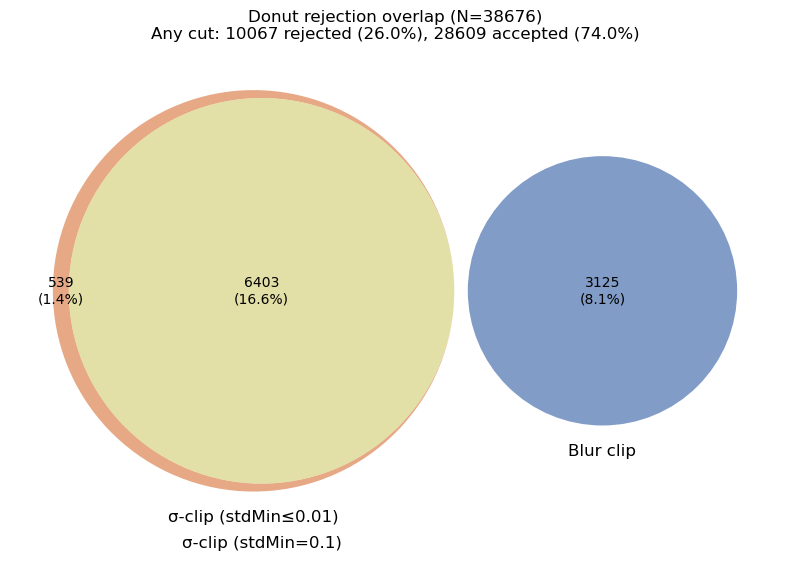

In [73]:
# pip install matplotlib-venn if needed
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Build rejection sets (indices of rejected donuts)
rejected_blur = set(df.index[~df['blur_accepted']])
rejected_s01 = set(df.index[~df['sigma_0.01']])  # same as 0.005
rejected_s1 = set(df.index[~df['sigma_0.1']])

fig, ax = plt.subplots(figsize=(8, 6))
v = venn3(
    [rejected_blur, rejected_s01, rejected_s1],
    set_labels=('Blur clip', 'σ-clip (stdMin≤0.01)', 'σ-clip (stdMin=0.1)'),
    set_colors=('#4C72B0', '#DD8452', '#55A868'),
    alpha=0.7,
    ax=ax,
)

# Add counts as percentages too
for label_id in v.subset_labels:
    if label_id is not None and label_id.get_text() != '0':
        count = int(label_id.get_text())
        label_id.set_text(f"{count}\n({count/n_total:.1%})")

# Total rejected (union of all)
all_rejected = rejected_blur | rejected_s01 | rejected_s1
ax.set_title(
    f"Donut rejection overlap (N={n_total})\n"
    f"Any cut: {len(all_rejected)} rejected ({len(all_rejected)/n_total:.1%}), "
    f"{n_total - len(all_rejected)} accepted ({(n_total - len(all_rejected))/n_total:.1%})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

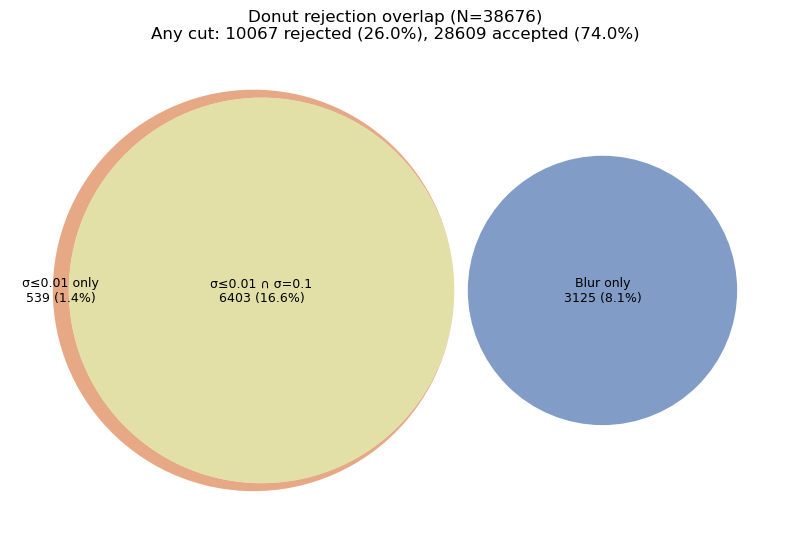

In [75]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

rejected_blur = set(df.index[~df['blur_accepted']])
rejected_s01 = set(df.index[~df['sigma_0.01']])
rejected_s1 = set(df.index[~df['sigma_0.1']])

fig, ax = plt.subplots(figsize=(8, 6))
v = venn3(
    [rejected_blur, rejected_s01, rejected_s1],
    set_labels=('', '', ''),  # suppress default external labels
    set_colors=('#4C72B0', '#DD8452', '#55A868'),
    alpha=0.7,
    ax=ax,
)

# Region IDs and their human-readable names
region_names = {
    '100': 'Blur only',
    '010': 'σ≤0.01 only',
    '001': 'σ=0.1 only',
    '110': 'Blur ∩ σ≤0.01',
    '101': 'Blur ∩ σ=0.1',
    '011': 'σ≤0.01 ∩ σ=0.1',
    '111': 'All three',
}

for region_id, name in region_names.items():
    label = v.get_label_by_id(region_id)
    if label is not None:
        count = int(label.get_text()) if label.get_text() != '' else 0
        if count > 0:
            label.set_text(f"{name}\n{count} ({count/n_total:.1%})")
            label.set_fontsize(9)
        else:
            label.set_text('')

all_rejected = rejected_blur | rejected_s01 | rejected_s1
ax.set_title(
    f"Donut rejection overlap (N={n_total})\n"
    f"Any cut: {len(all_rejected)} rejected ({len(all_rejected)/n_total:.1%}), "
    f"{n_total - len(all_rejected)} accepted ({(n_total - len(all_rejected))/n_total:.1%})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

Ok, show examples of each group: 

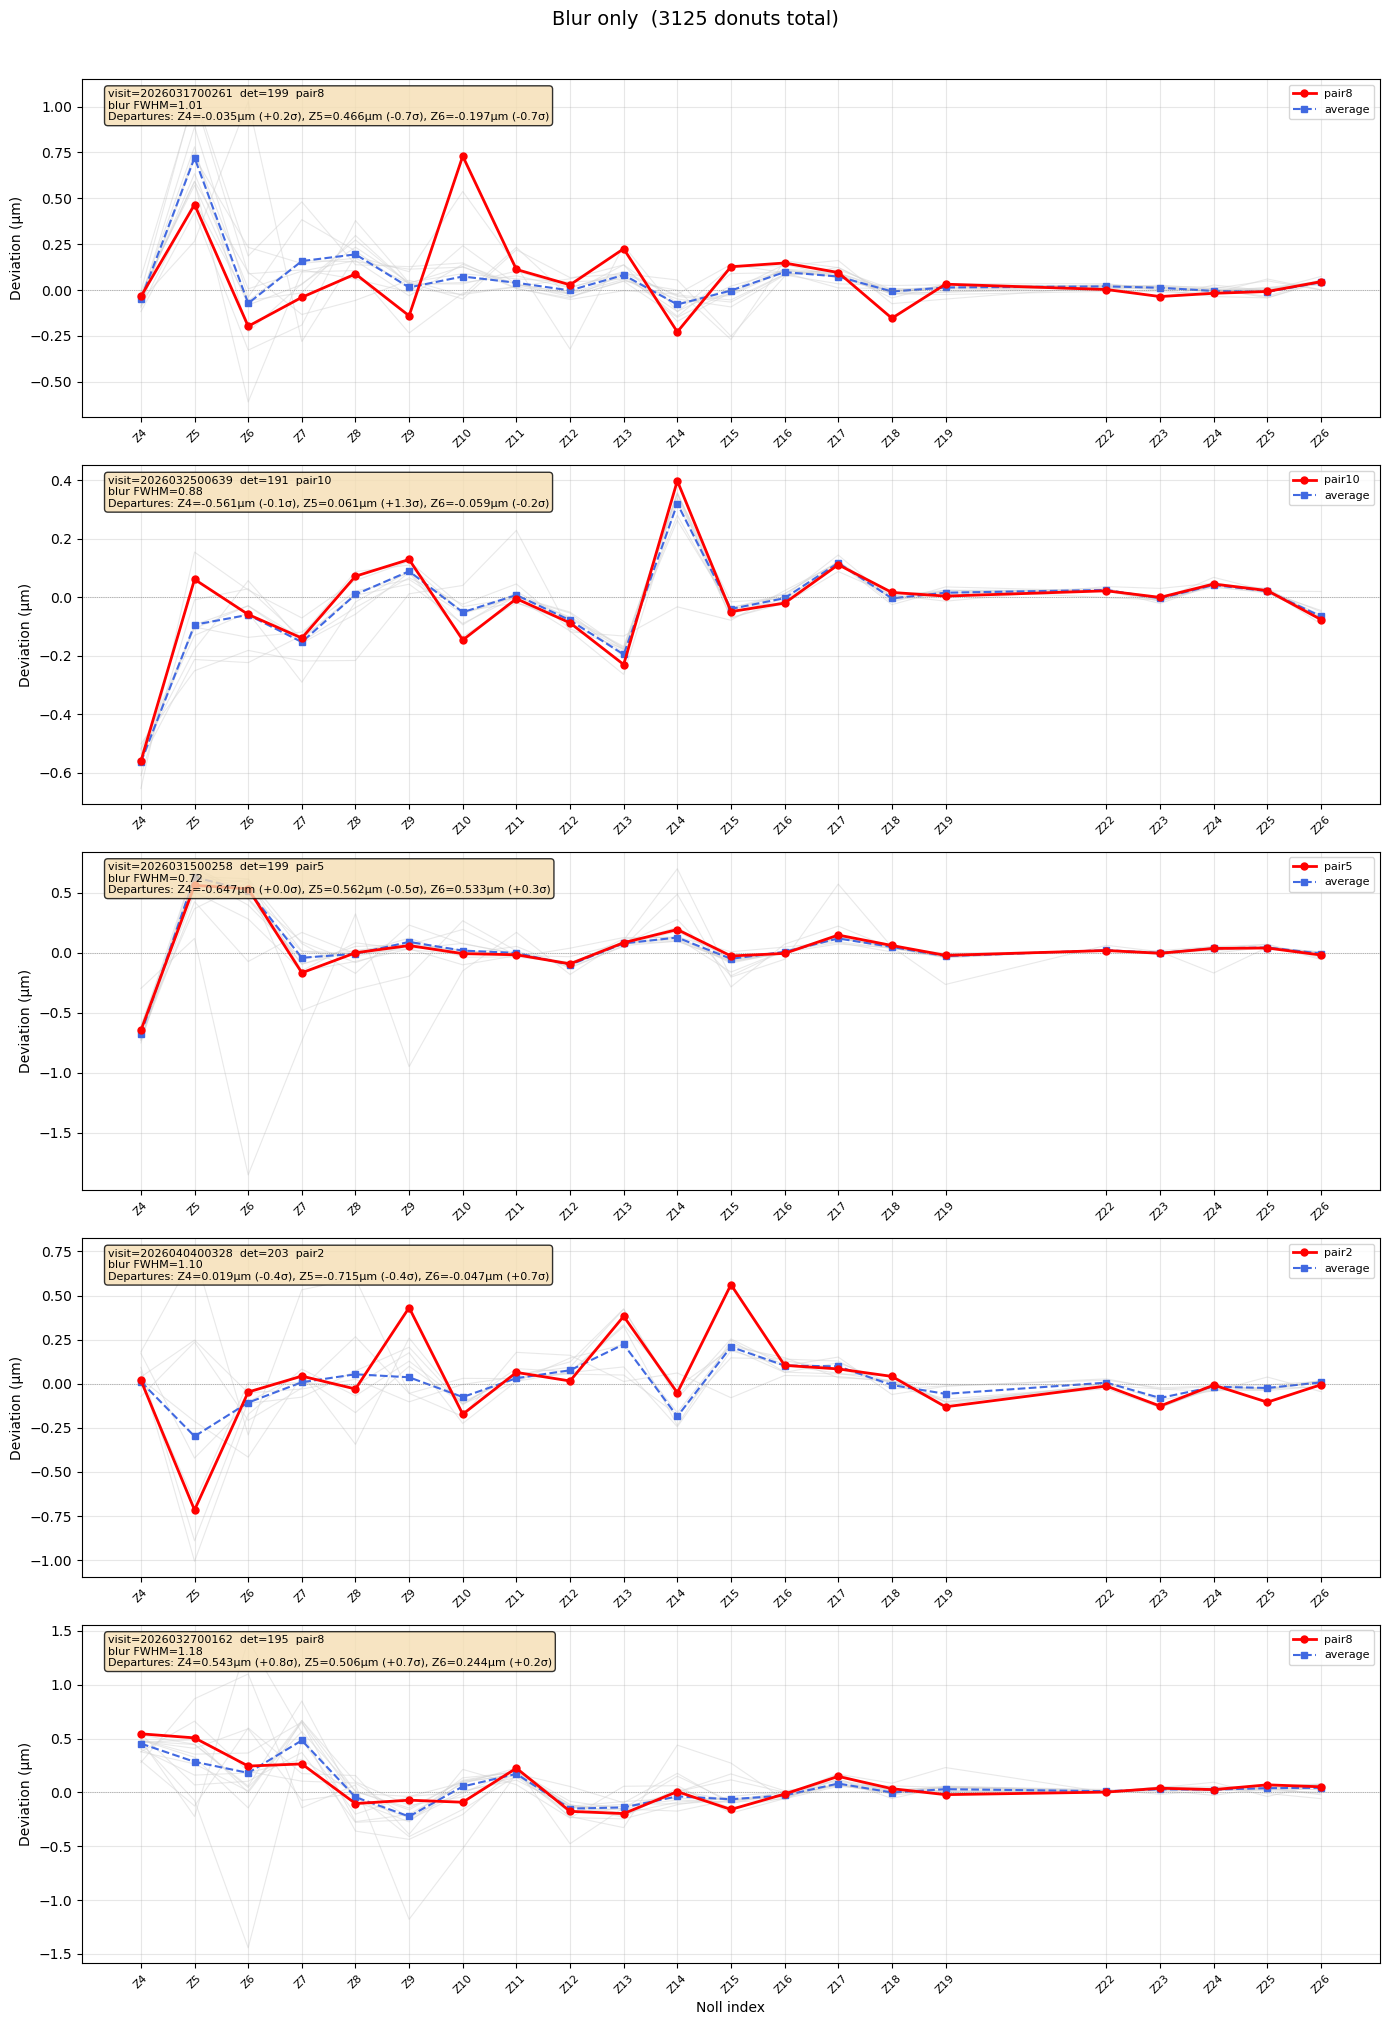

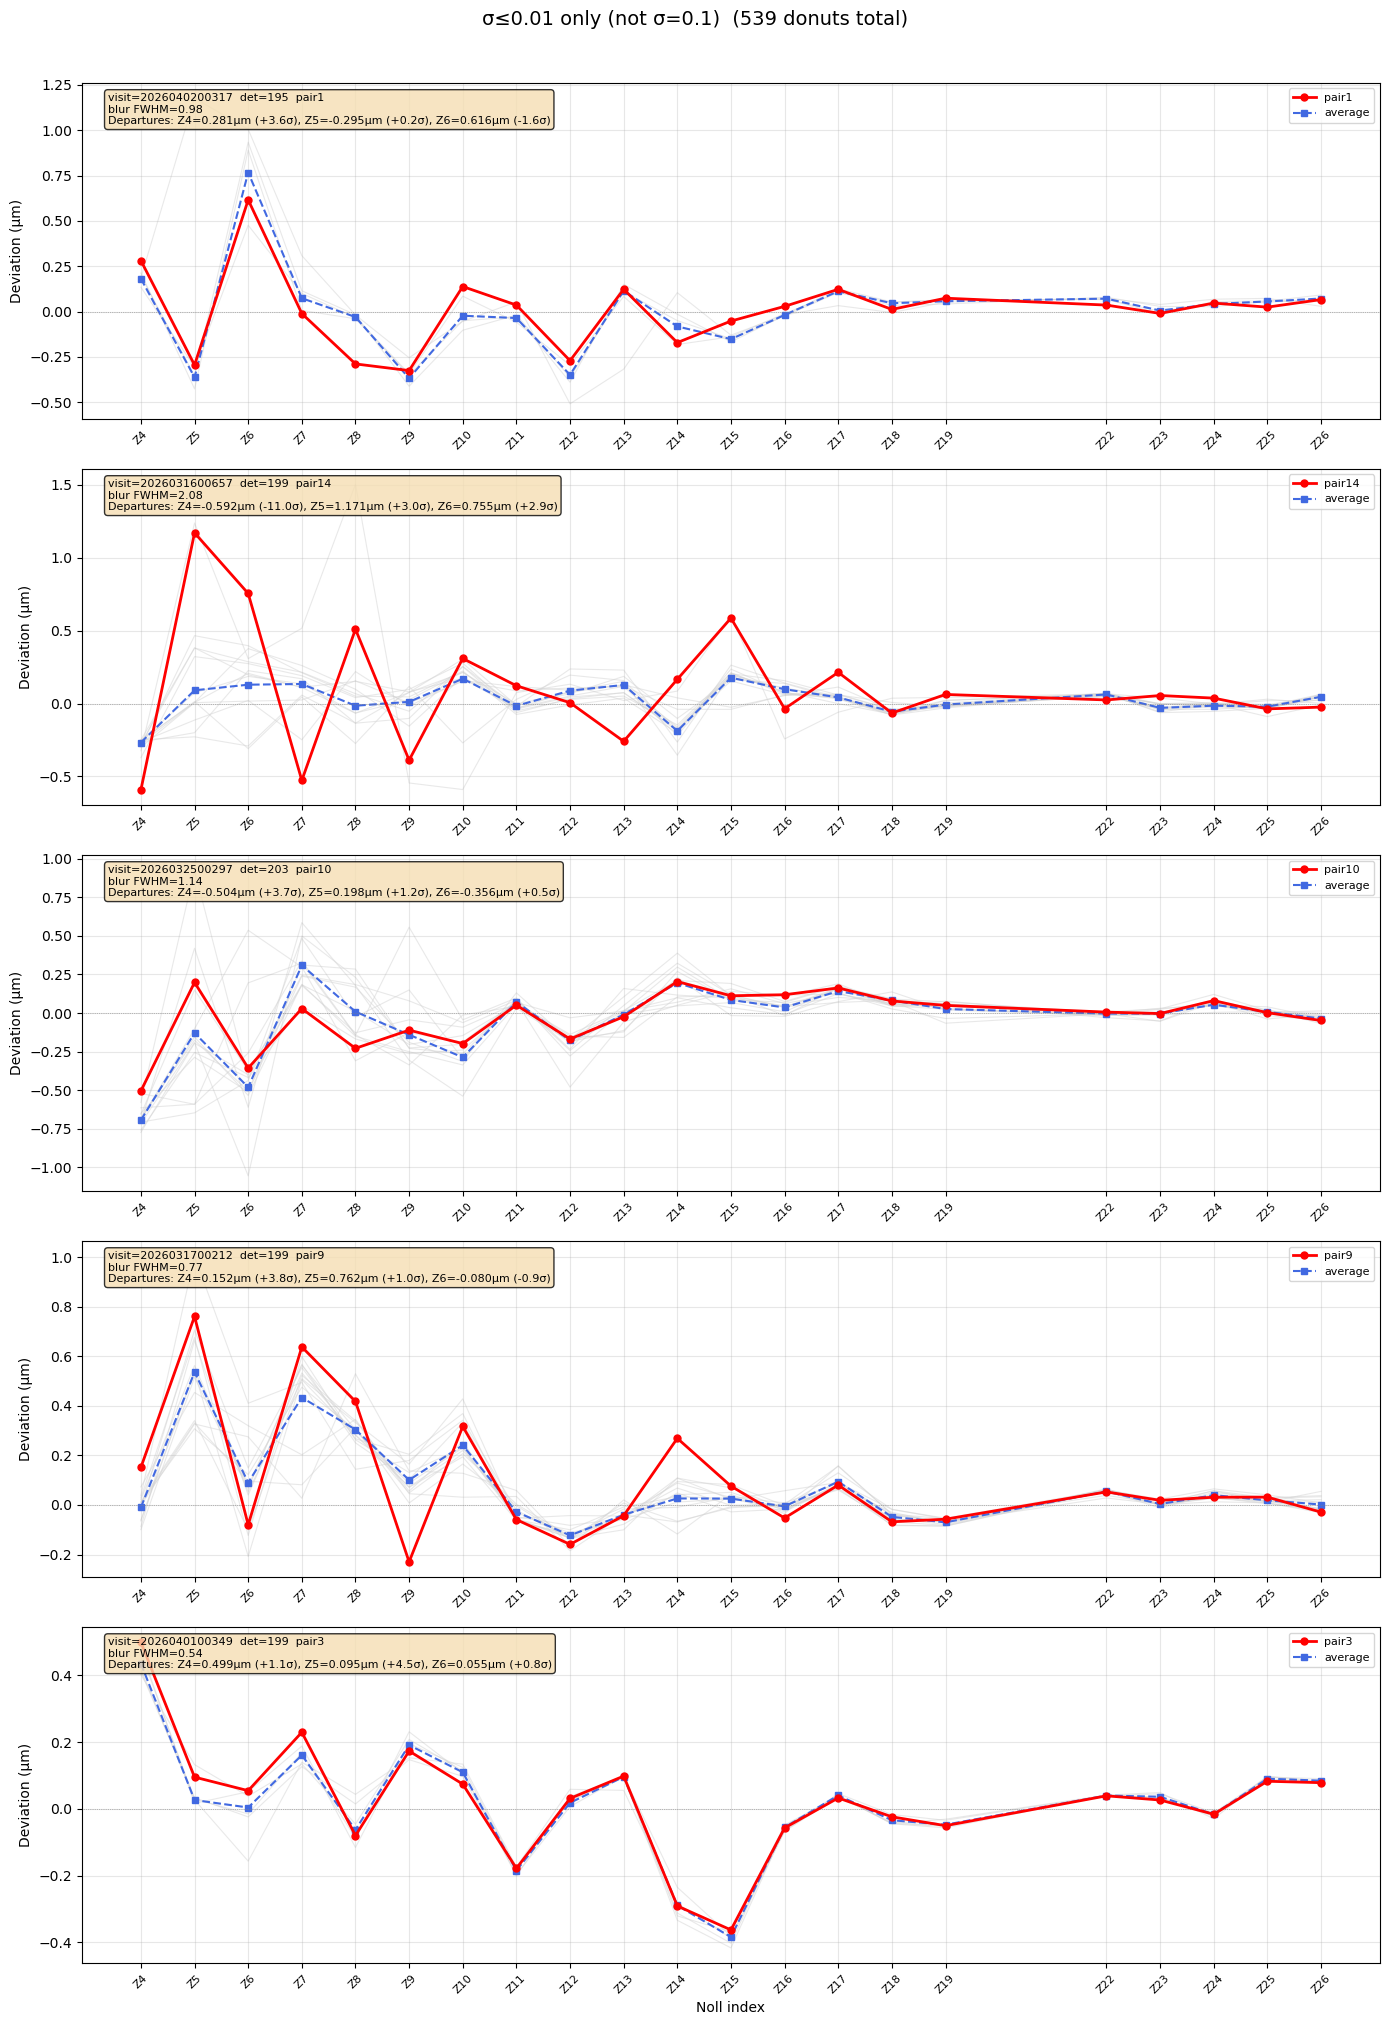

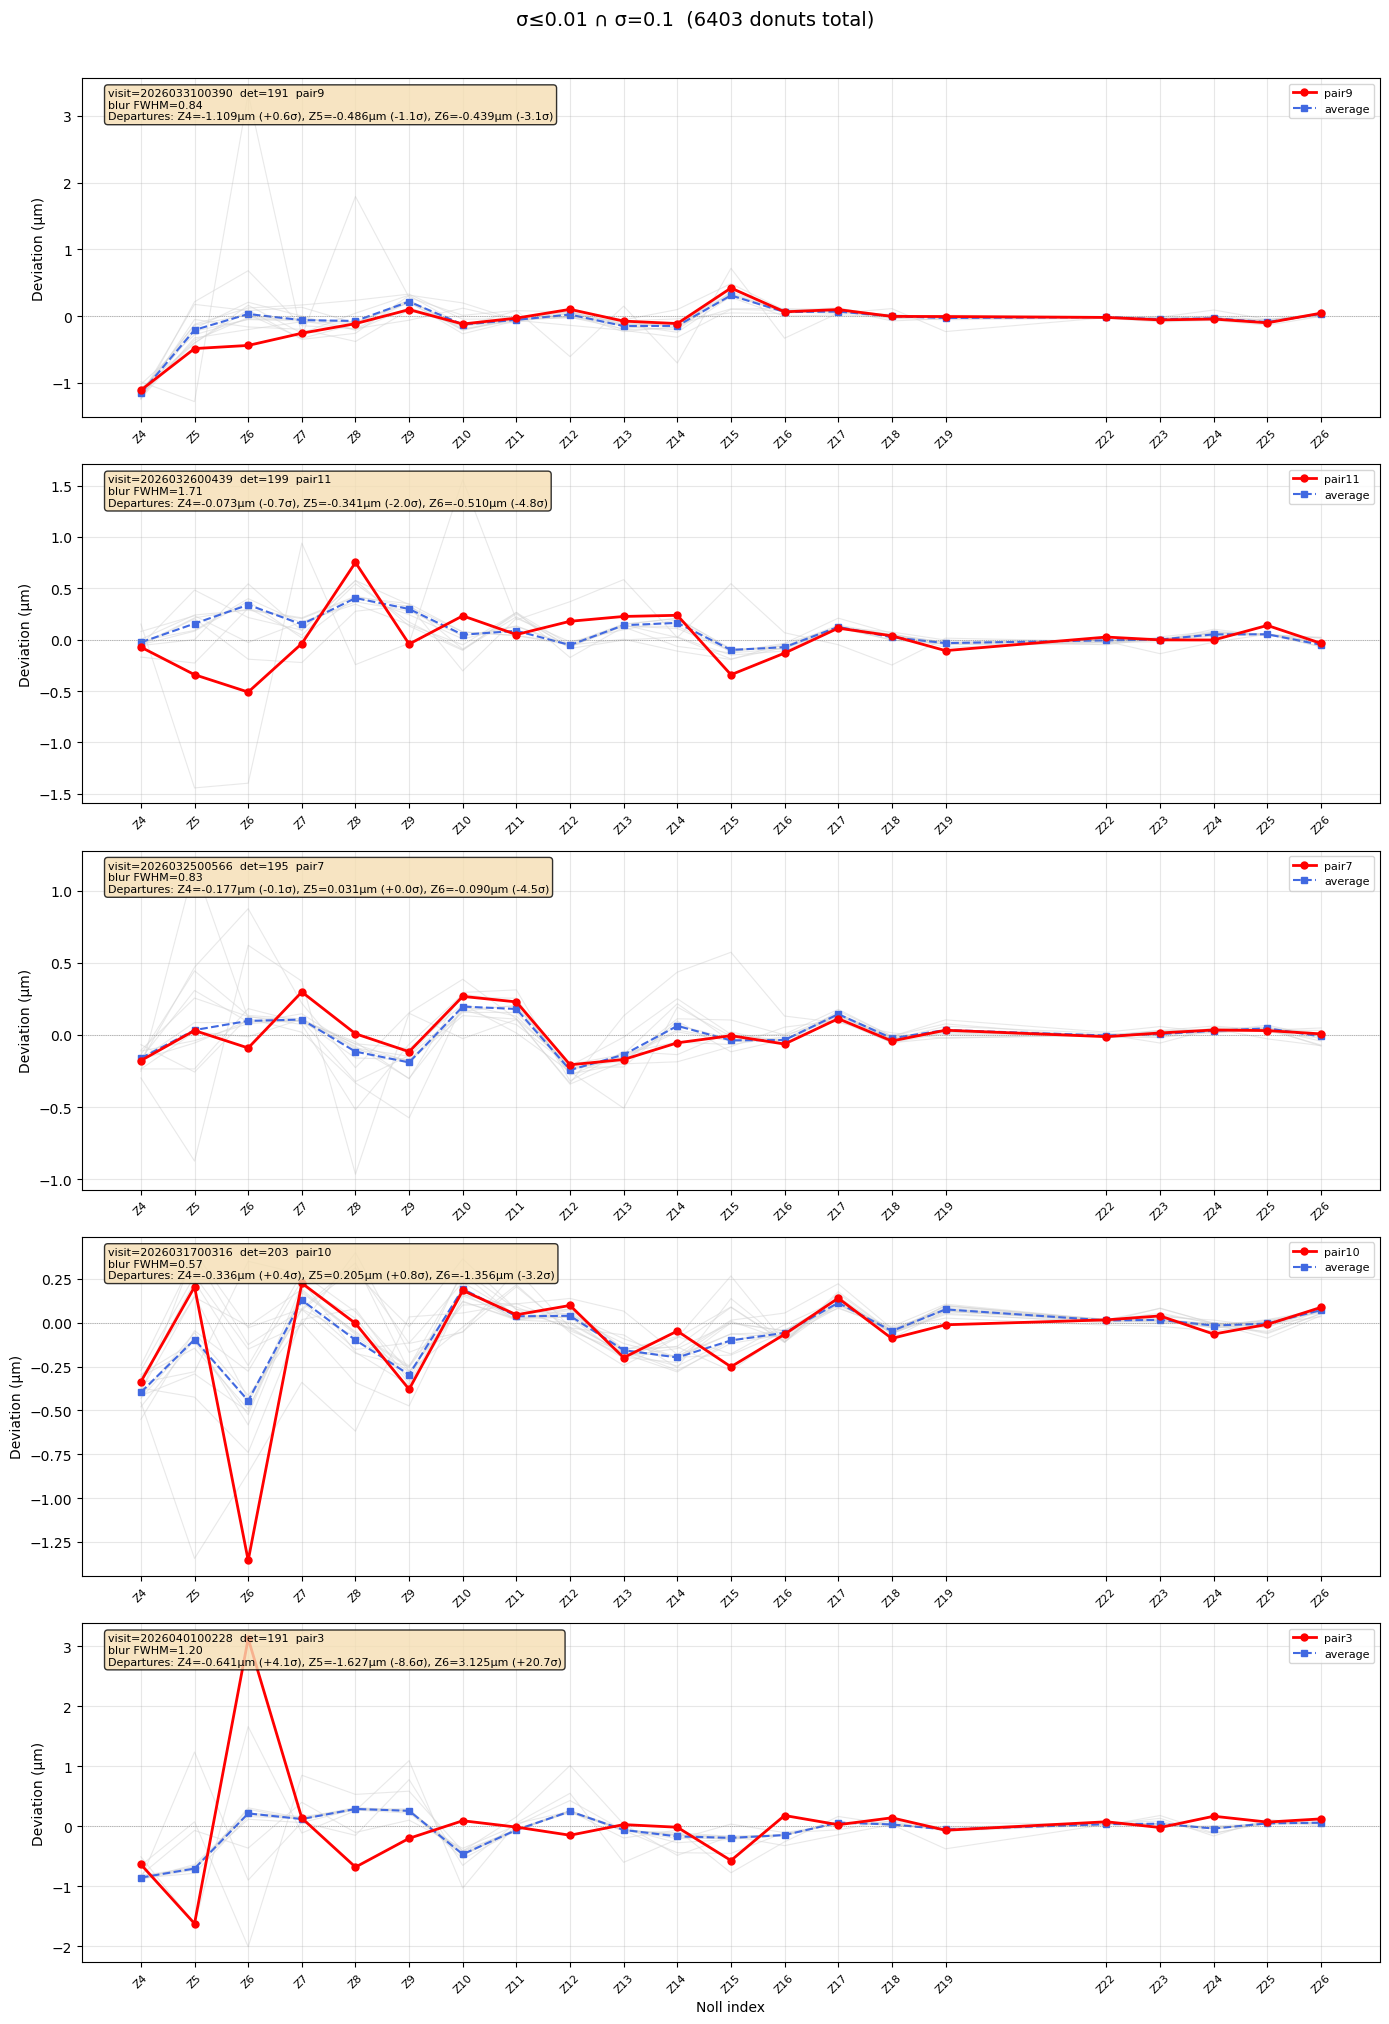

In [79]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.stats import mad_std
import numpy as np

# Build a lookup so we can go from df row back to the full table
df['visit'] = df['visit'].astype(int)
df['detector'] = df['detector'].astype(int)

# Define categories to inspect
categories = {
    'Blur only': df[~df['blur_accepted'] & df['sigma_0.01'] & df['sigma_0.1']],
    'σ≤0.01 only (not σ=0.1)': df[df['blur_accepted'] & ~df['sigma_0.01'] & df['sigma_0.1']],
    'σ≤0.01 ∩ σ=0.1': df[df['blur_accepted'] & ~df['sigma_0.01'] & ~df['sigma_0.1']],
}

dev_cols_first3 = ['Z4_deviation', 'Z5_deviation', 'Z6_deviation']
noll_indices = [4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,22,23,24,25,26]
dev_cols_all = [f'Z{j}_deviation' for j in noll_indices]

n_examples = 5

for cat_name, cat_df in categories.items():
    if len(cat_df) == 0:
        print(f"\n=== {cat_name}: no donuts in this category ===\n")
        continue

    sample = cat_df.sample(n=min(n_examples, len(cat_df)), random_state=42)

    fig, axes = plt.subplots(
        len(sample), 1, figsize=(14, 4 * len(sample)),
        squeeze=False,
    )
    fig.suptitle(f"{cat_name}  ({len(cat_df)} donuts total)", fontsize=14, y=1.01)

    for idx, (_, row) in enumerate(sample.iterrows()):
        ax = axes[idx, 0]
        visit, det = int(row['visit']), int(row['detector'])
        pair_label = row['pair']
        zk = results[(visit, det)]

        # Get all non-average pairs
        pairs = zk[zk['label'] != 'average']
        pair_idx = list(pairs['label']).index(pair_label)

        # Get blur fwhm for this donut
        fwhm_list = zk.meta.get('estimatorInfo', {}).get('fwhm', [])
        blur_val = fwhm_list[pair_idx] if pair_idx < len(fwhm_list) else np.nan

        # Plot all donuts from this visit/det as gray lines
        for i, p in enumerate(pairs):
            dev_vals = [p[c].to('um').value for c in dev_cols_all]
            ax.plot(noll_indices, dev_vals, '-', color='lightgray',
                    alpha=0.5, lw=0.8, zorder=1)

        # Highlight the rejected donut in red
        target = pairs[pairs['label'] == pair_label][0]
        target_devs = [target[c].to('um').value for c in dev_cols_all]
        ax.plot(noll_indices, target_devs, 'o-', color='red',
                lw=2, ms=5, zorder=3, label=pair_label)

        # Plot the average as blue dashed
        avg = zk[zk['label'] == 'average'][0]
        avg_devs = [avg[c].to('um').value for c in dev_cols_all]
        ax.plot(noll_indices, avg_devs, 's--', color='royalblue',
                lw=1.5, ms=4, zorder=2, label='average')

        # Compute sigma departure for Z4, Z5, Z6
        sigma_info = []
        for dc in dev_cols_first3:
            all_vals = np.array([p[dc].to('um').value for p in pairs])
            med = np.nanmedian(all_vals)
            mad = mad_std(all_vals[~np.isnan(all_vals)])
            val = target[dc].to('um').value
            sigma_dep = (val - med) / mad if mad > 0 else np.nan
            sigma_info.append(f"{dc.replace('_deviation','')}={val:.3f}µm ({sigma_dep:+.1f}σ)")

        # Annotation
        info_text = (
            f"visit={visit}  det={det}  {pair_label}\n"
            f"blur FWHM={blur_val:.2f}\n"
            f"Departures: {', '.join(sigma_info)}"
        )
        ax.text(
            0.02, 0.97, info_text, transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        )

        ax.set_ylabel('Deviation (µm)')
        ax.set_xticks(noll_indices)
        ax.set_xticklabels([f'Z{j}' for j in noll_indices], fontsize=8, rotation=45)
        ax.axhline(0, color='gray', ls=':', lw=0.5)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)

    axes[-1, 0].set_xlabel('Noll index')
    plt.tight_layout()
    plt.show()

In [81]:
zk['label']

average
pair1
pair2
pair3
pair4
pair5
pair6
pair7
pair8
pair9
pair10


In [82]:
df

,visit,detector,pair,blur_accepted,sigma_0.005,sigma_0.01,sigma_0.1,rejected_by
0,2026031500335,203,pair1,True,True,True,True,"(none,)"
1,2026031500335,203,pair2,True,True,True,True,"(none,)"
2,2026031500335,203,pair3,True,True,True,True,"(none,)"
3,2026031500335,203,pair4,True,True,True,True,"(none,)"
4,2026031500335,203,pair5,True,True,True,True,"(none,)"
...,...,...,...,...,...,...,...,...
38671,2026040200266,199,pair7,False,True,True,True,"(blur,)"
38672,2026040200299,191,pair1,True,True,True,True,"(none,)"
38673,2026040200299,191,pair2,True,True,True,True,"(none,)"
38674,2026040200299,191,pair3,True,True,True,True,"(none,)"


In [83]:
stamps_intra = butler.get(
        'donutStampsIntra',
        collections=[collection],
        visit=2026031500335, detector=203, instrument='LSSTCam',
    )

In [84]:
len(stamps_intra)

15

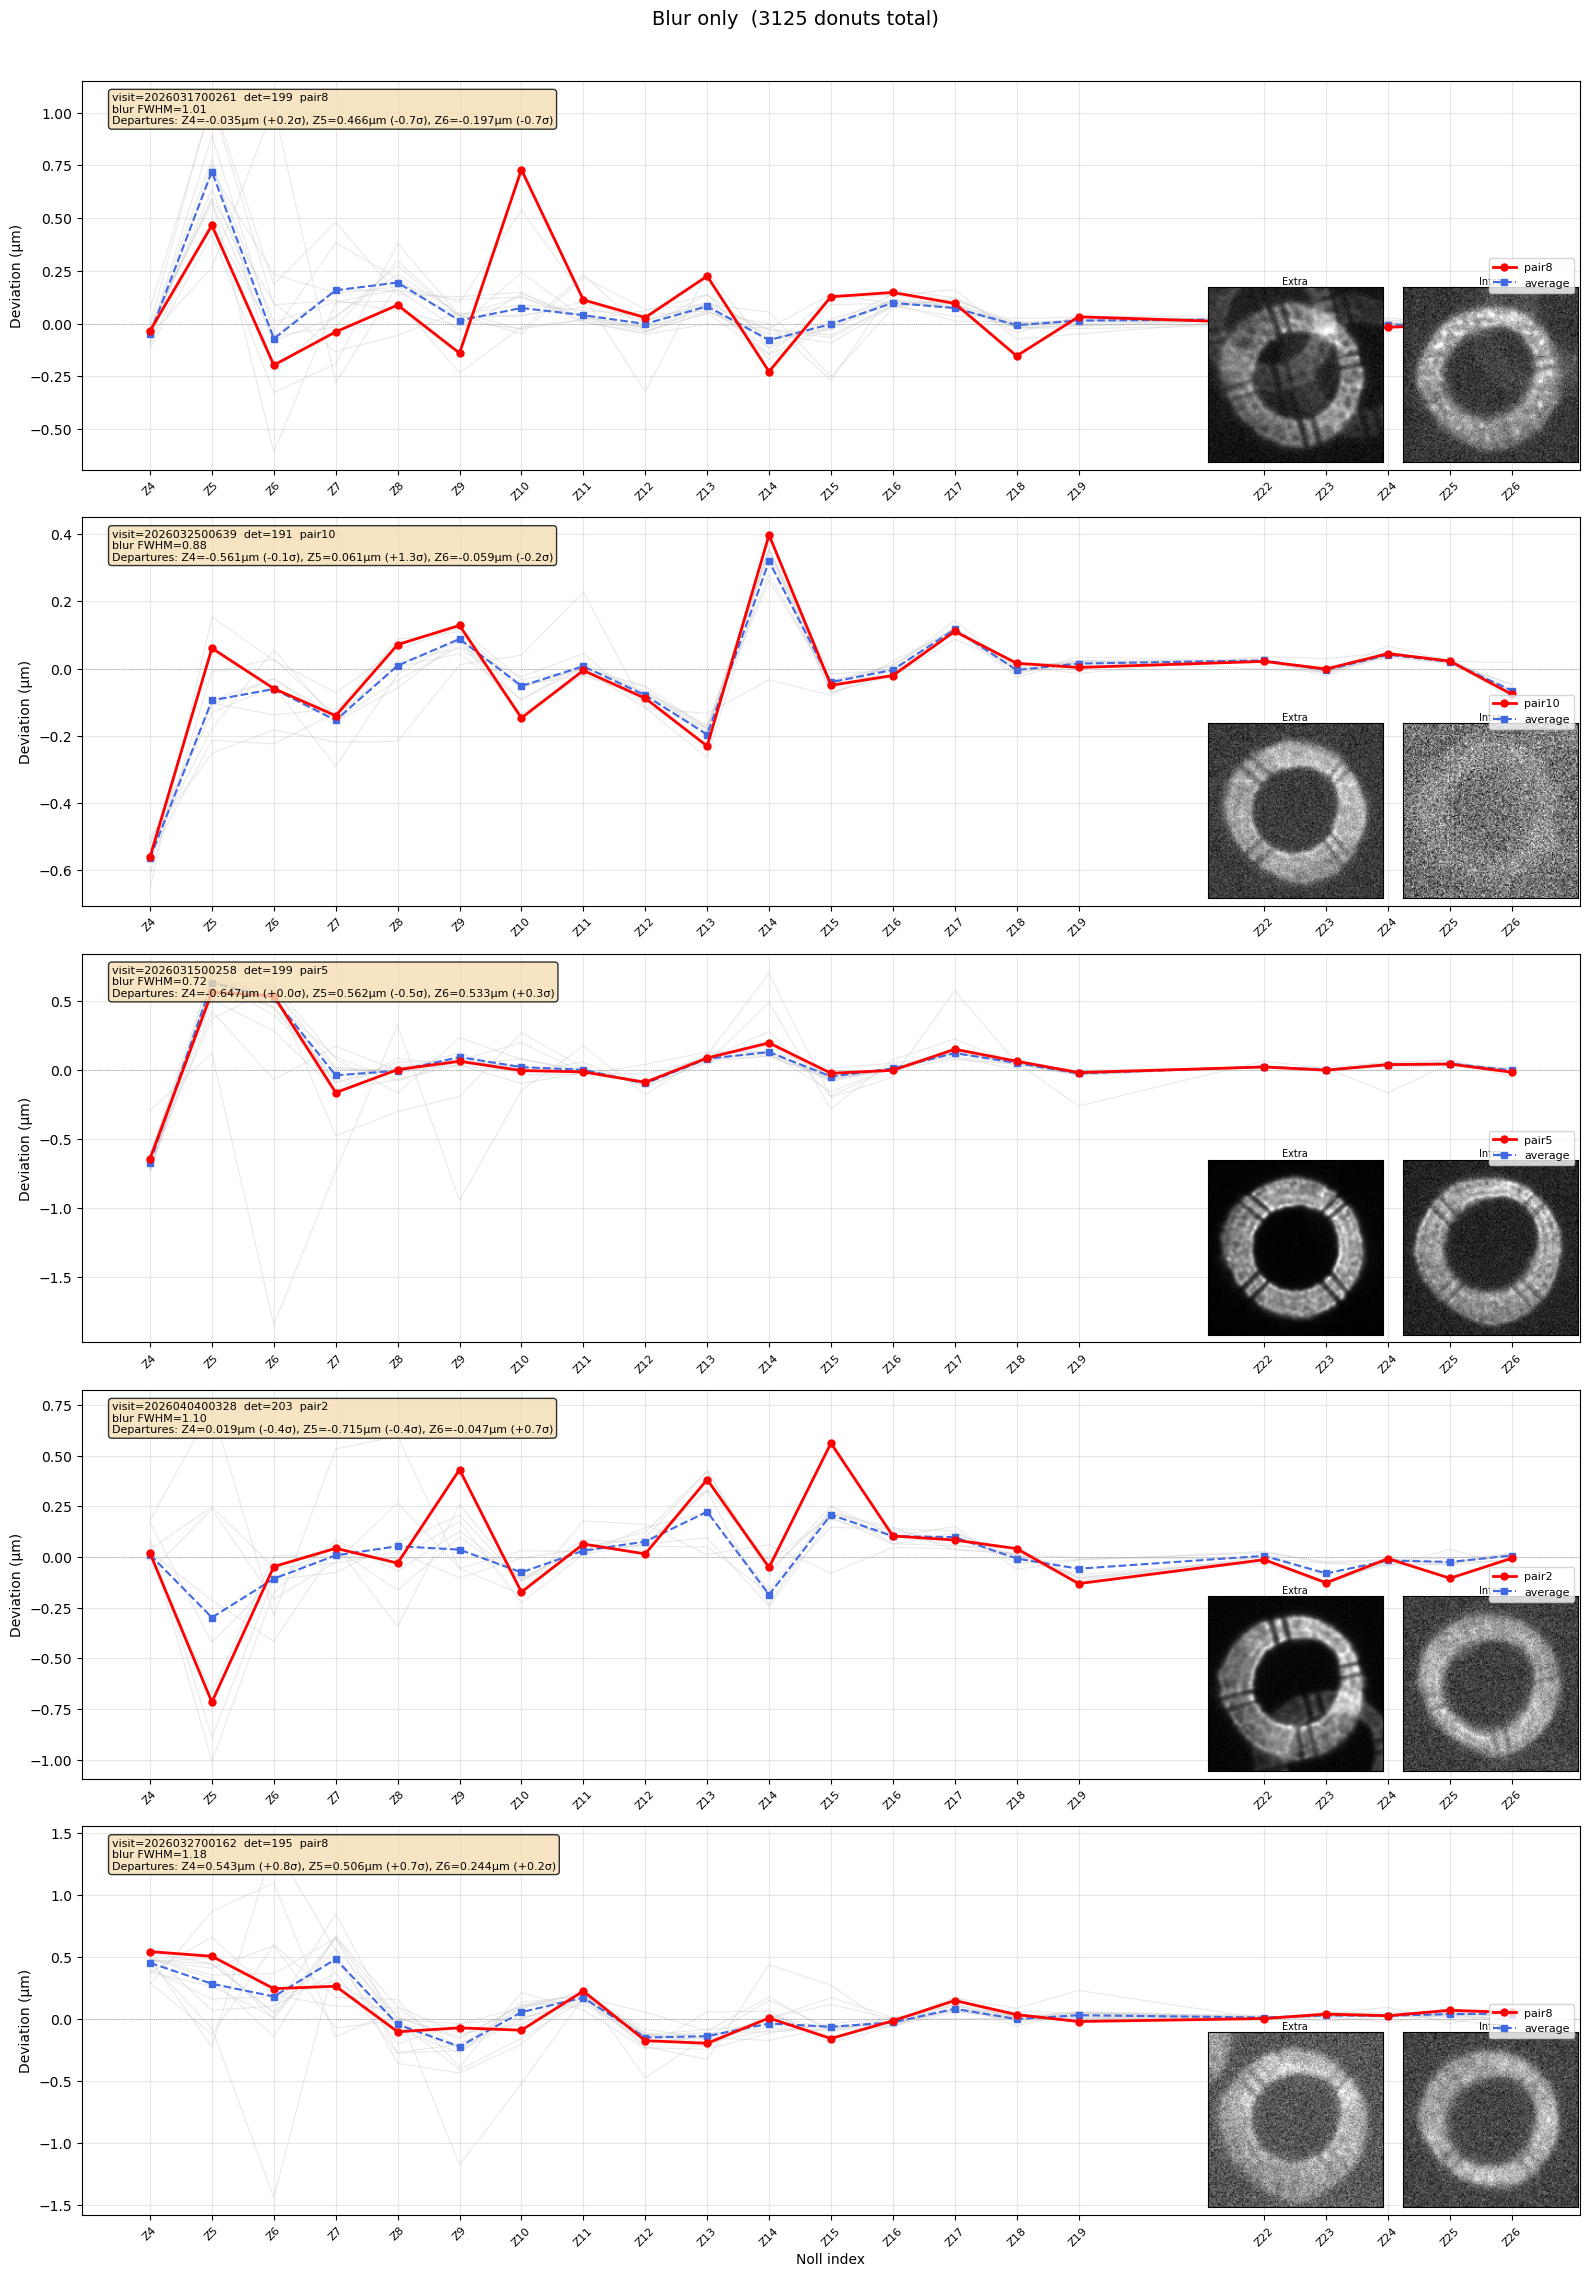

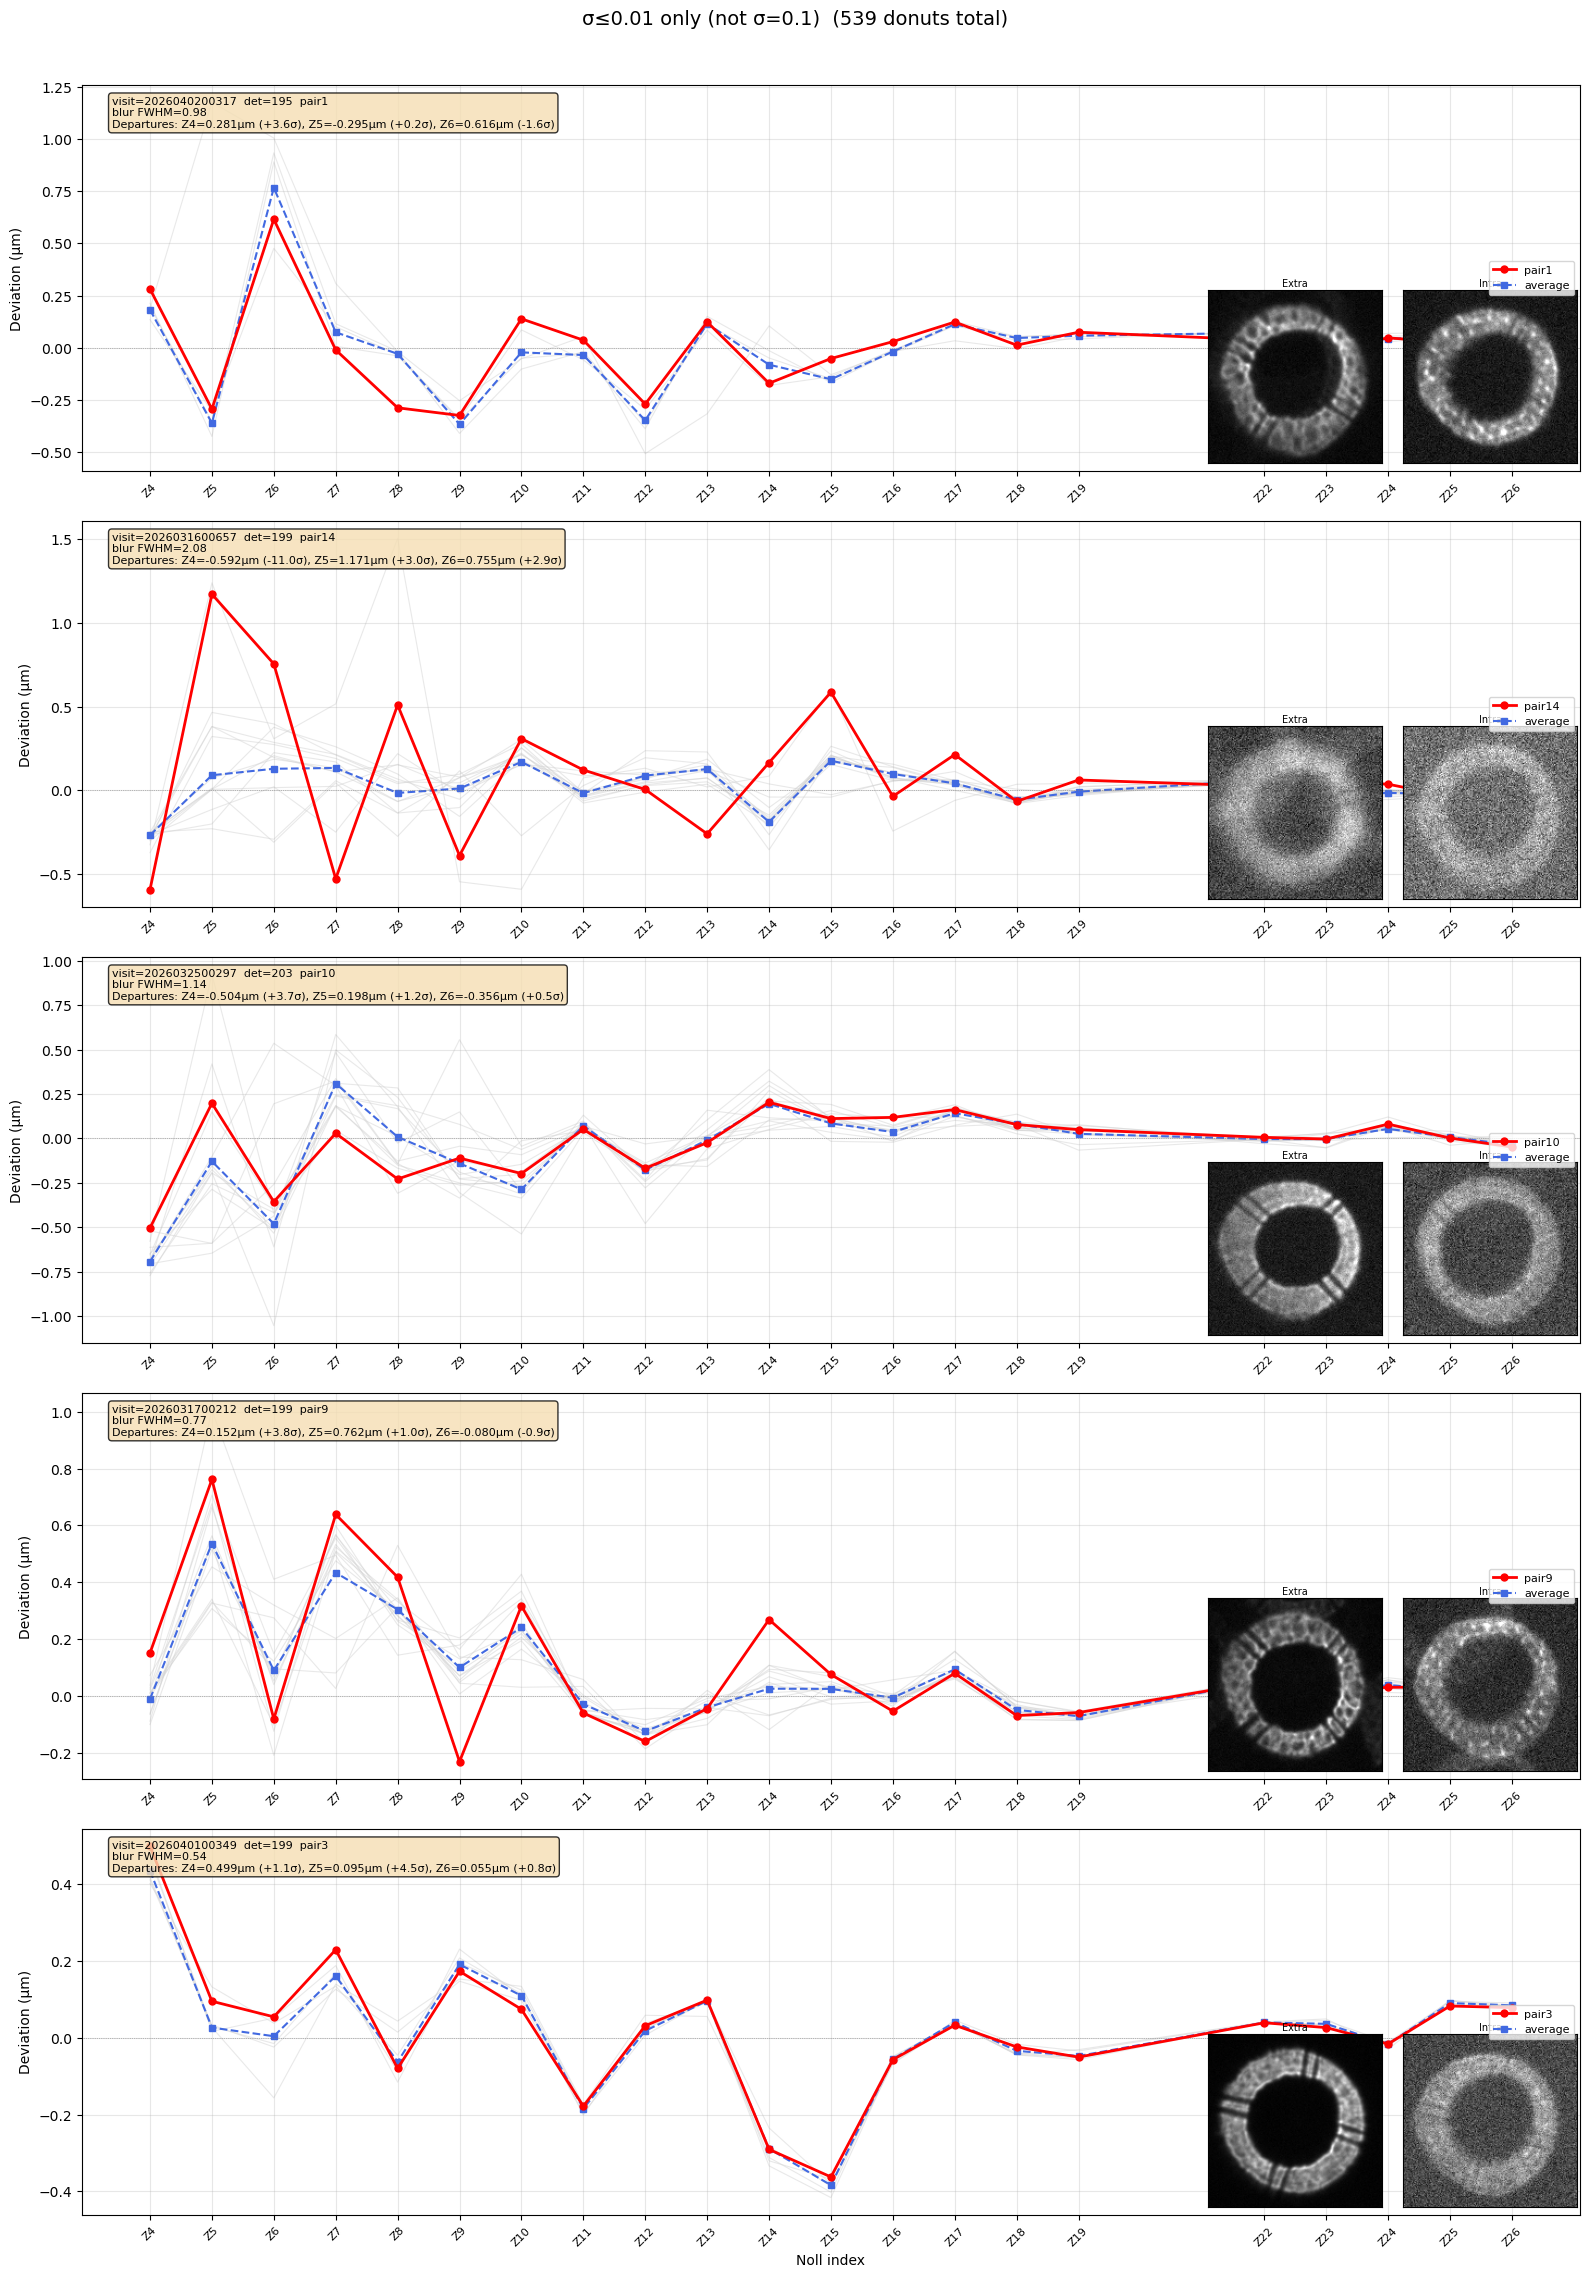

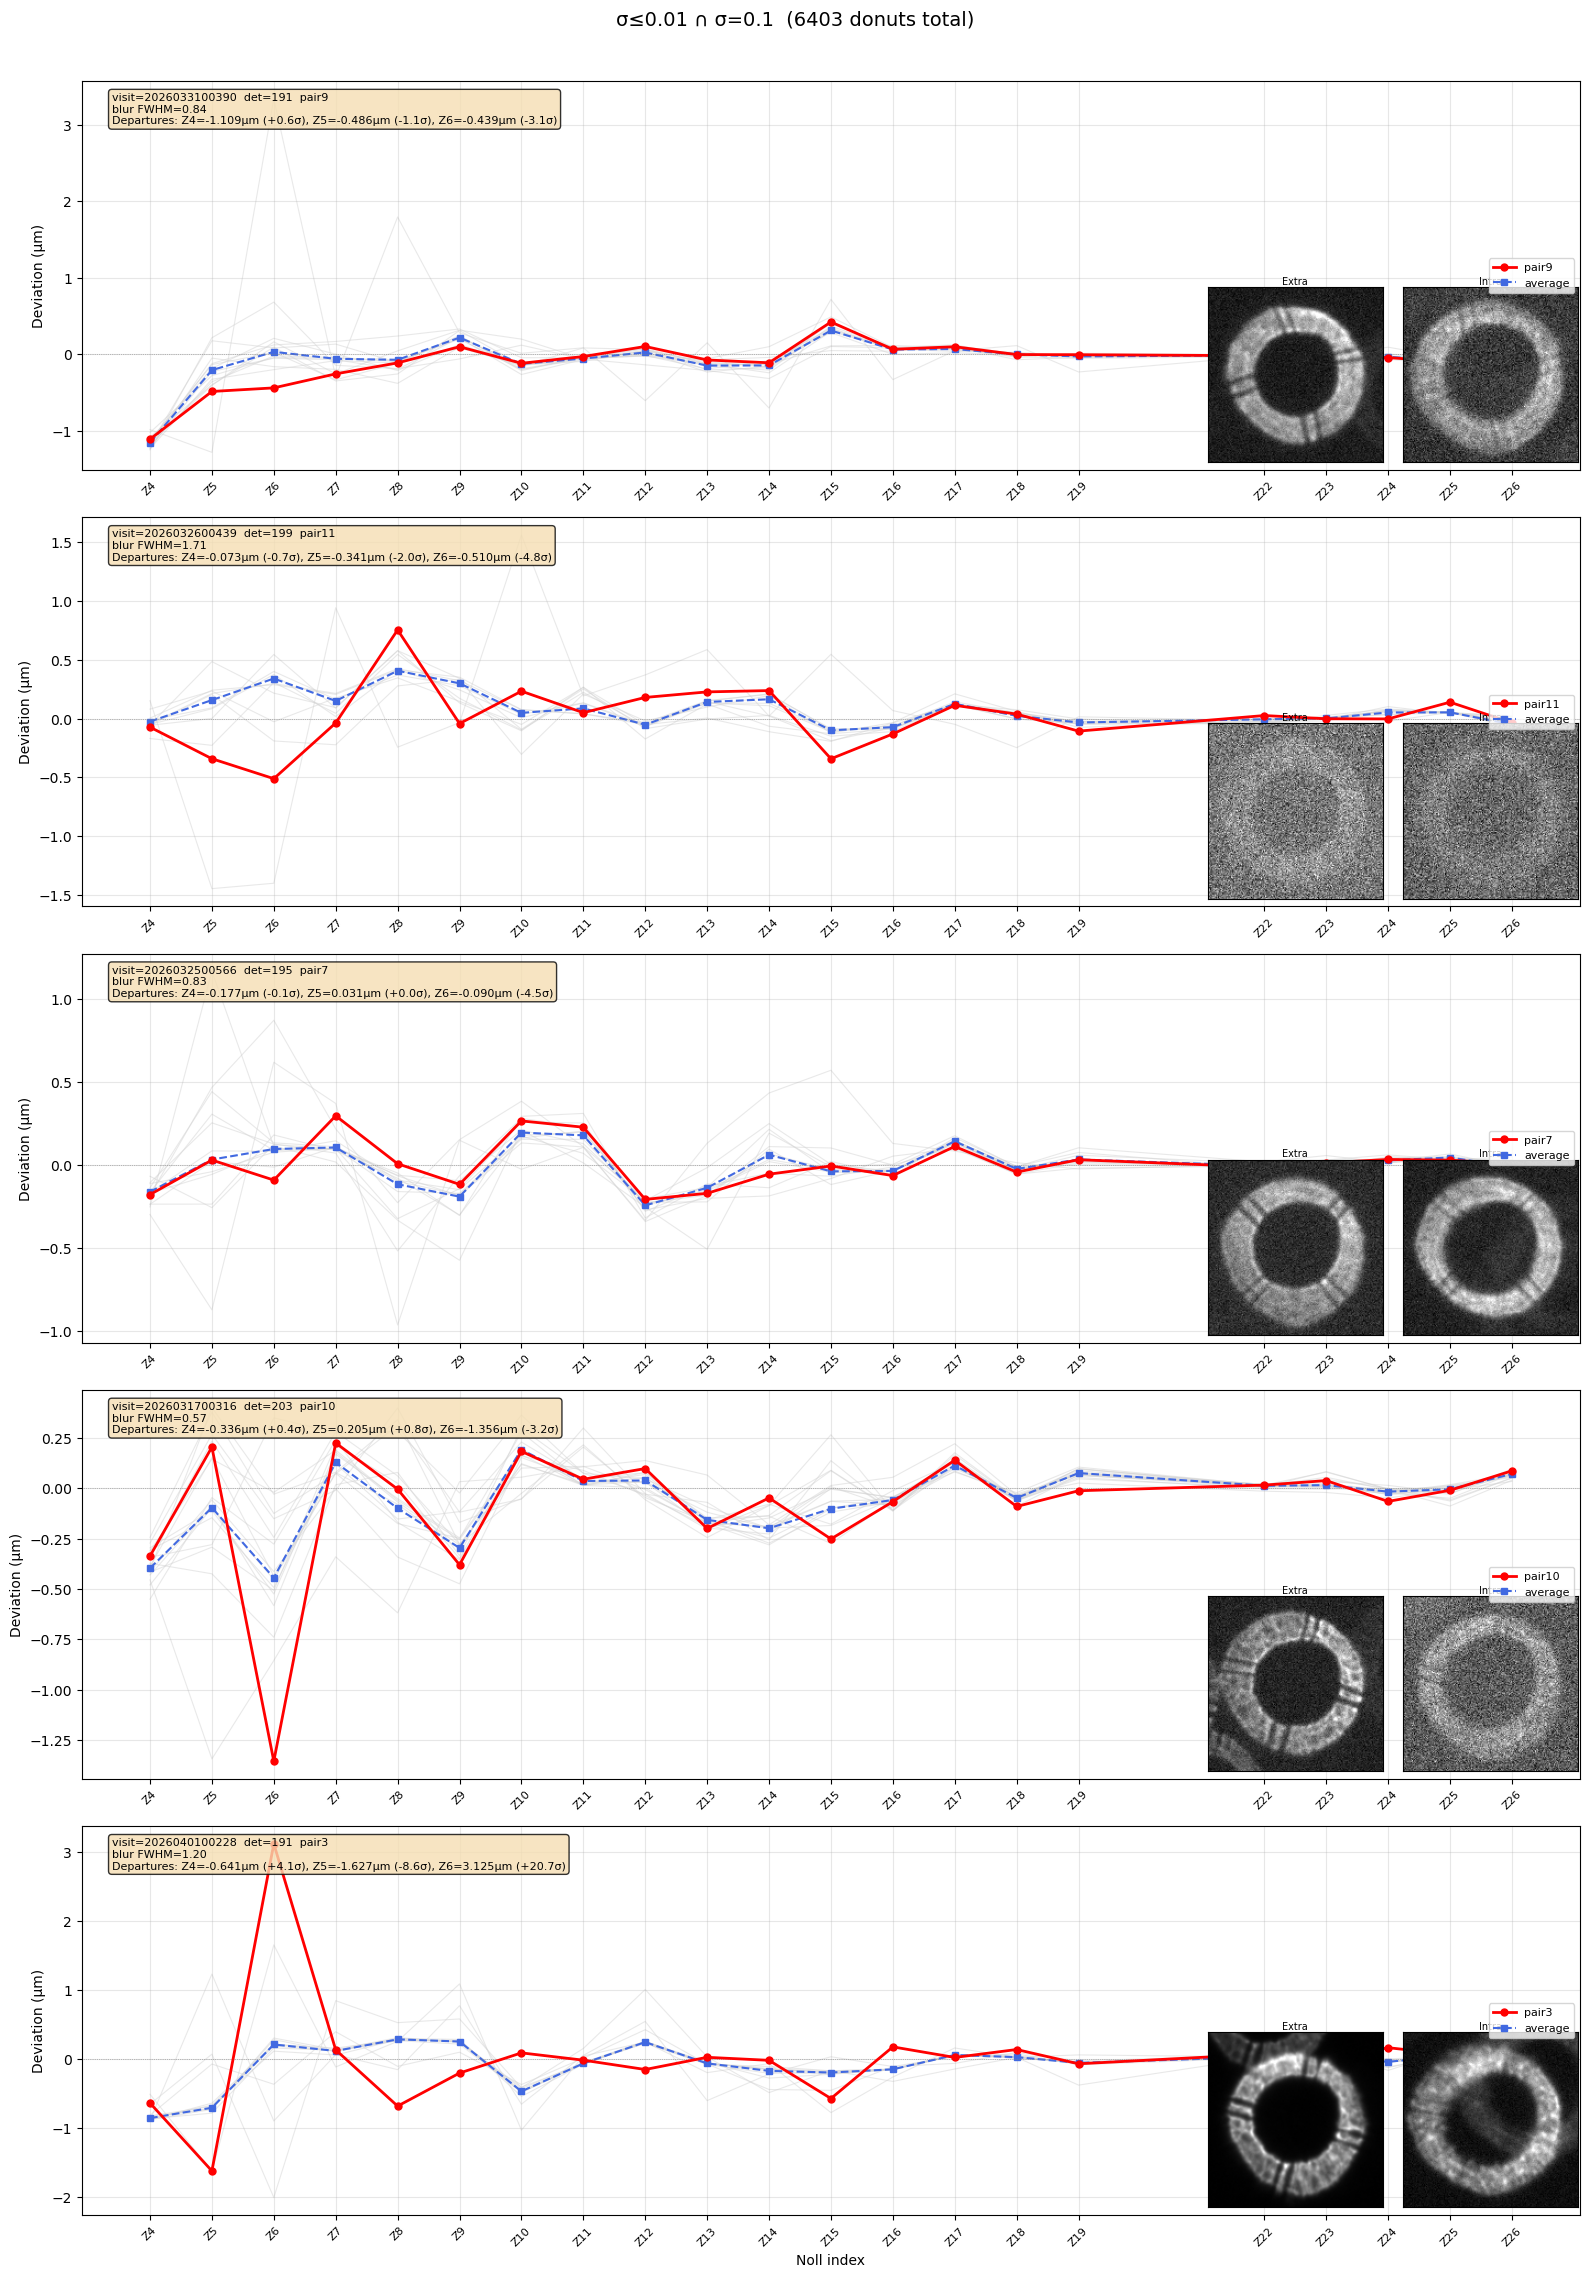

In [91]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as np
from astropy.stats import mad_std
from astropy.visualization import ZScaleInterval

zscale = ZScaleInterval()

def add_stamp_insets(ax, butler, collection, visit, det, intra_donut_id, extra_donut_id):
    """Add inset axes showing extra and intra donut stamps, matched by donut_id."""
    try:
        stamps_extra = butler.get(
            'donutStampsExtra',
            collections=[collection],
            visit=visit, detector=det, instrument='LSSTCam',
        )
        stamps_intra = butler.get(
            'donutStampsIntra',
            collections=[collection],
            visit=visit, detector=det, instrument='LSSTCam',
        )
    except Exception as e:
        ax.text(0.85, 0.5, "Stamps\nnot found",
                transform=ax.transAxes, fontsize=7, ha='center', va='center')
        return

    for stamps, donut_id, label, x0 in [
        (stamps_extra, extra_donut_id, 'Extra', 0.75),
        (stamps_intra, intra_donut_id, 'Intra', 0.88),
    ]:
        if not donut_id:
            continue
        ids = list(stamps.metadata.getArray('DONUT_ID'))
        if donut_id not in ids:
            continue
        stamp_idx = ids.index(donut_id)

        img = stamps[stamp_idx].stamp_im.getImage().getArray()
        vmin, vmax = zscale.get_limits(img)

        inset = ax.inset_axes([x0, 0.02, 0.12, 0.45])
        inset.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
        inset.set_title(label, fontsize=7, pad=2)
        inset.set_xticks([])
        inset.set_yticks([])

n_examples = 5

for cat_name, cat_df in categories.items():
    if len(cat_df) == 0:
        print(f"\n=== {cat_name}: no donuts in this category ===\n")
        continue

    sample = cat_df.sample(n=min(n_examples, len(cat_df)), random_state=42)

    fig, axes = plt.subplots(
        len(sample), 1, figsize=(16, 4.5 * len(sample)),
        squeeze=False,
    )
    fig.suptitle(f"{cat_name}  ({len(cat_df)} donuts total)", fontsize=14, y=1.01)

    for idx, (_, row) in enumerate(sample.iterrows()):
        ax = axes[idx, 0]
        visit, det = int(row['visit']), int(row['detector'])
        pair_label = row['pair']
        zk = results[(visit, det)]

        pairs = zk[zk['label'] != 'average']
        pair_idx = list(pairs['label']).index(pair_label)

        fwhm_list = zk.meta.get('estimatorInfo', {}).get('fwhm', [])
        blur_val = fwhm_list[pair_idx] if pair_idx < len(fwhm_list) else np.nan

        # All donuts as gray
        for i, p in enumerate(pairs):
            dev_vals = [p[c].to('um').value for c in dev_cols_all]
            ax.plot(noll_indices, dev_vals, '-', color='lightgray',
                    alpha=0.5, lw=0.8, zorder=1)

        # Rejected donut in red
        target = pairs[pairs['label'] == pair_label][0]
        target_devs = [target[c].to('um').value for c in dev_cols_all]
        ax.plot(noll_indices, target_devs, 'o-', color='red',
                lw=2, ms=5, zorder=3, label=pair_label)

        # Average in blue
        avg = zk[zk['label'] == 'average'][0]
        avg_devs = [avg[c].to('um').value for c in dev_cols_all]
        ax.plot(noll_indices, avg_devs, 's--', color='royalblue',
                lw=1.5, ms=4, zorder=2, label='average')

        # Sigma departures for Z4, Z5, Z6
        sigma_info = []
        for dc in dev_cols_first3:
            all_vals = np.array([p[dc].to('um').value for p in pairs])
            med = np.nanmedian(all_vals)
            mad = mad_std(all_vals[~np.isnan(all_vals)])
            val = target[dc].to('um').value
            sigma_dep = (val - med) / mad if mad > 0 else np.nan
            sigma_info.append(f"{dc.replace('_deviation','')}={val:.3f}µm ({sigma_dep:+.1f}σ)")

        info_text = (
            f"visit={visit}  det={det}  {pair_label}\n"
            f"blur FWHM={blur_val:.2f}\n"
            f"Departures: {', '.join(sigma_info)}"
        )
        ax.text(
            0.02, 0.97, info_text, transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        )

        # Add donut stamp insets
        # Get donut IDs for this pair
        intra_donut_id = str(target['intra_donut_id'])
        extra_donut_id = str(target['extra_donut_id'])

        add_stamp_insets(ax, butler, collection, visit, det, intra_donut_id, extra_donut_id)
        ax.set_ylabel('Deviation (µm)')
        ax.set_xticks(noll_indices)
        ax.set_xticklabels([f'Z{j}' for j in noll_indices], fontsize=8, rotation=45)
        ax.axhline(0, color='gray', ls=':', lw=0.5)
        ax.legend(loc='center right', fontsize=8)
        ax.grid(alpha=0.3)

    axes[-1, 0].set_xlabel('Noll index')
    plt.tight_layout()
    plt.show()
    plt.savefig()